In [4]:
# ============================================================
# SPY MODELLING DATA PREPARATION
# Common setup for all ERNN and QRNN specifications
# ============================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

BASE_SEED = 2026

random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BASE_SEED)


# ------------------------------------------------------------
# 2. Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# 3. Load the scaled SPY dataset
# ------------------------------------------------------------

DATA_PATH = (
    Path.home()
    / "SPY_features_scaled.csv"
)

df = pd.read_csv(
    DATA_PATH,
    index_col="Date",
    parse_dates=True
)

df = (
    df
    .sort_index()
    .drop_duplicates()
    .dropna()
    .copy()
)


# ------------------------------------------------------------
# 4. Define response and predictor variables
# ------------------------------------------------------------

target_col = "log_return"

feature_cols = [
    "Volatility",
    "RSI_14",
    "ATR_14",
    "QQQ_LogReturns",
    "VIX_LogChange",
    "Volume_LogChange",
]

required_cols = [target_col] + feature_cols

missing_cols = [
    column
    for column in required_cols
    if column not in df.columns
]

if missing_cols:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_cols)
    )


# ------------------------------------------------------------
# 5. Chronological 70%–15%–15% split
# ------------------------------------------------------------

train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[
    :train_size
].copy()

val_df = df.iloc[
    train_size:train_size + val_size
].copy()

test_df = df.iloc[
    train_size + val_size:
].copy()


# ------------------------------------------------------------
# 6. Convert the three samples to PyTorch tensors
# ------------------------------------------------------------

X_train = torch.tensor(
    train_df[feature_cols].to_numpy(),
    dtype=torch.float32,
    device=device
)

y_train = torch.tensor(
    train_df[target_col].to_numpy(),
    dtype=torch.float32,
    device=device
)

X_val = torch.tensor(
    val_df[feature_cols].to_numpy(),
    dtype=torch.float32,
    device=device
)

y_val = torch.tensor(
    val_df[target_col].to_numpy(),
    dtype=torch.float32,
    device=device
)

X_test = torch.tensor(
    test_df[feature_cols].to_numpy(),
    dtype=torch.float32,
    device=device
)

y_test = torch.tensor(
    test_df[target_col].to_numpy(),
    dtype=torch.float32,
    device=device
)


# Compatibility names used in some existing notebooks
X_test_q = X_test
y_test_q = y_test


# ------------------------------------------------------------
# 7. Quantile and expectile levels
# ------------------------------------------------------------

levels = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

alpha_levels = levels
tau_levels = levels


# ------------------------------------------------------------
# 8. Verify the modelling data
# ------------------------------------------------------------

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

assert X_train.shape[1] == len(feature_cols)
assert torch.isfinite(X_train).all()
assert torch.isfinite(X_val).all()
assert torch.isfinite(X_test).all()

split_summary = pd.DataFrame({
    "Sample": [
        "Training",
        "Validation",
        "Test"
    ],
    "Observations": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "Start": [
        train_df.index.min().date(),
        val_df.index.min().date(),
        test_df.index.min().date()
    ],
    "End": [
        train_df.index.max().date(),
        val_df.index.max().date(),
        test_df.index.max().date()
    ]
})

display(split_summary)

print("Input features:", feature_cols)
print("Number of predictors:", len(feature_cols))
print("X_train shape:", tuple(X_train.shape))
print("X_val shape:  ", tuple(X_val.shape))
print("X_test shape: ", tuple(X_test.shape))

Device: cpu


,Sample,Observations,Start,End
0,Training,2219,2014-01-23,2022-11-11
1,Validation,475,2022-11-14,2024-10-04
2,Test,476,2024-10-07,2026-08-31


Input features: ['Volatility', 'RSI_14', 'ATR_14', 'QQQ_LogReturns', 'VIX_LogChange', 'Volume_LogChange']
Number of predictors: 6
X_train shape: (2219, 6)
X_val shape:   (475, 6)
X_test shape:  (476, 6)


# Original tunning

In [6]:
# ============================================================
# ORIGINAL TUNING — SPY HYBRID QRNN A SELF-LAGGED
# Seven separately estimated quantile levels
# 200 Optuna trials per level
# ============================================================

import copy
import json
import time
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ------------------------------------------------------------
# 1. Required objects and output directory
# ------------------------------------------------------------

required_objects = [
    "X_train",
    "y_train",
    "X_val",
    "y_val",
    "X_test",
    "y_test",
    "device",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing data-preparation objects:\n"
        + ", ".join(missing_objects)
        + "\nRun the SPY modelling-data preparation cell first."
    )

MODEL_NAME = "spy_qrnn_a_self"
N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026

ALPHA_LEVELS = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

OUTPUT_DIR = Path(
    "spy_original_tuning_results"
) / MODEL_NAME

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory:", OUTPUT_DIR.resolve())


# ------------------------------------------------------------
# 2. Reproducibility helper
# ------------------------------------------------------------

def set_model_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------
# 3. ALD negative log-likelihood
# ------------------------------------------------------------

def hybrid_qrnn_loss(
    y,
    q_hybrid,
    sigma_al,
    alpha
):
    """
    Asymmetric Laplace negative log-likelihood.

    Parameters
    ----------
    y : tensor, shape (T,)
        Observed SPY log returns.

    q_hybrid : tensor, shape (T,)
        Hybrid conditional quantile forecasts.

    sigma_al : scalar tensor
        Positive ALD scale parameter.

    alpha : float
        Quantile level.
    """

    eps = torch.finfo(
        q_hybrid.dtype
    ).eps

    sigma_al = torch.clamp(
        sigma_al,
        min=eps
    )

    alpha_tensor = torch.as_tensor(
        alpha,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )

    residual = y - q_hybrid

    indicator = (
        residual < 0
    ).to(q_hybrid.dtype)

    check_loss = residual * (
        alpha_tensor - indicator
    )

    nll = (
        -torch.log(
            alpha_tensor
            * (1.0 - alpha_tensor)
        )
        + torch.log(sigma_al)
        + check_loss / sigma_al
    )

    return nll.mean()


# ------------------------------------------------------------
# 4. A-form self-lagged hybrid recursion
# ------------------------------------------------------------

def compute_hybrid_quantile_location_self_a(
    y,
    X,
    beta1,
    beta2,
    beta3,
    fnn_model,
    psi
):
    """
    Hybrid QRNN A self-lagged recursion.

    The statistical component uses its own previous
    pure CAViaR forecast:

        s_t = beta1*s_(t-1)
              + beta2*y_(t-1)^+
              + beta3*y_(t-1)^-

    The complete hybrid forecast is:

        q_t = psi*s_t + (1-psi)*f_t
    """

    number_of_observations = len(y)

    fnn_output = (
        fnn_model(X)
        .squeeze(-1)
    )

    # Device-safe scalar initial values
    zero_value = y.new_zeros(())

    caviar_forecasts = [
        zero_value
    ]

    hybrid_forecasts = [
        zero_value
    ]

    for time_index in range(
        1,
        number_of_observations
    ):
        previous_return = y[
            time_index - 1
        ]

        positive_return = torch.clamp(
            previous_return,
            min=0
        )

        negative_return = torch.clamp(
            -previous_return,
            min=0
        )

        caviar_value = (
            beta1
            * caviar_forecasts[
                time_index - 1
            ]
            + beta2 * positive_return
            + beta3 * negative_return
        )

        hybrid_value = (
            psi * caviar_value
            + (1.0 - psi)
            * fnn_output[time_index]
        )

        caviar_forecasts.append(
            caviar_value
        )

        hybrid_forecasts.append(
            hybrid_value
        )

    caviar_forecasts = torch.stack(
        caviar_forecasts
    )

    hybrid_forecasts = torch.stack(
        hybrid_forecasts
    )

    return (
        hybrid_forecasts,
        caviar_forecasts
    )


# ------------------------------------------------------------
# 5. Hybrid QRNN A self-lagged model
# ------------------------------------------------------------

class HybridQRNN_A_Self(nn.Module):

    def __init__(
        self,
        input_dim,
        config
    ):
        super().__init__()

        self.eps = 1e-6

        # Trainable CAViaR and hybrid parameters
        self.beta1_raw = nn.Parameter(
            torch.tensor(1.386)
        )

        self.beta2_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.beta3_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.psi_raw = nn.Parameter(
            torch.tensor(0.0)
        )

        self.sigma_raw = nn.Parameter(
            torch.tensor(0.5)
        )

        layers = []
        previous_dimension = input_dim

        for layer_index in range(
            config["n_hidden_layers"]
        ):
            hidden_dimension = config[
                f"hidden_dim_{layer_index}"
            ]

            layers.append(
                nn.Linear(
                    previous_dimension,
                    hidden_dimension
                )
            )

            if config["layernorm"]:
                layers.append(
                    nn.LayerNorm(
                        hidden_dimension
                    )
                )

            layers.append(
                self.get_activation(
                    config["activation"]
                )
            )

            if config["dropout"] > 0:
                layers.append(
                    nn.Dropout(
                        config["dropout"]
                    )
                )

            previous_dimension = (
                hidden_dimension
            )

        layers.append(
            nn.Linear(
                previous_dimension,
                1
            )
        )

        self.fnn = nn.Sequential(
            *layers
        )

        self.initialise_weights(
            config["weight_init"]
        )

    @staticmethod
    def get_activation(name):

        activations = {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }

        return activations[name]

    def initialise_weights(
        self,
        weight_initialisation
    ):
        for module in self.fnn.modules():

            if not isinstance(
                module,
                nn.Linear
            ):
                continue

            if weight_initialisation == "glorot":
                nn.init.xavier_uniform_(
                    module.weight
                )

            elif weight_initialisation == "he":
                nn.init.kaiming_uniform_(
                    module.weight
                )

            if module.bias is not None:
                nn.init.zeros_(
                    module.bias
                )

    def forward(
        self,
        y,
        X
    ):
        beta1 = torch.sigmoid(
            self.beta1_raw
        )

        beta2 = F.softplus(
            self.beta2_raw
        )

        beta3 = F.softplus(
            self.beta3_raw
        )

        psi = torch.sigmoid(
            self.psi_raw
        )

        sigma = (
            F.softplus(
                self.sigma_raw
            )
            + self.eps
        )

        hybrid_forecast, caviar_forecast = (
            compute_hybrid_quantile_location_self_a(
                y=y,
                X=X,
                beta1=beta1,
                beta2=beta2,
                beta3=beta3,
                fnn_model=self.fnn,
                psi=psi
            )
        )

        return (
            hybrid_forecast,
            sigma,
            caviar_forecast
        )


# ------------------------------------------------------------
# 6. Quantile coverage-ratio diagnostic
# ------------------------------------------------------------

def calculate_crp(
    y,
    quantile_forecast,
    alpha
):
    """
    Tail coverage ratio used in the original Bitcoin ranking.

    An ideal value is one. The ranking penalty is:

        (CRP - 1)^2
    """

    if alpha <= 0.5:

        empirical_tail_probability = (
            y <= quantile_forecast
        ).float().mean().item()

        target_tail_probability = alpha

    else:

        empirical_tail_probability = (
            y > quantile_forecast
        ).float().mean().item()

        target_tail_probability = (
            1.0 - alpha
        )

    crp = (
        empirical_tail_probability
        / target_tail_probability
    )

    crp_penalty = (
        crp - 1.0
    ) ** 2

    return (
        crp,
        crp_penalty,
        empirical_tail_probability
    )


# ------------------------------------------------------------
# 7. Optuna search space
# ------------------------------------------------------------

def suggest_qrnn_config(trial):

    config = {
        "n_hidden_layers":
            trial.suggest_int(
                "n_hidden_layers",
                1,
                3
            ),

        "activation":
            trial.suggest_categorical(
                "activation",
                [
                    "relu",
                    "elu",
                    "gelu",
                    "tanh"
                ]
            ),

        "dropout":
            trial.suggest_float(
                "dropout",
                0.0,
                0.5
            ),

        "layernorm":
            trial.suggest_categorical(
                "layernorm",
                [
                    True,
                    False
                ]
            ),

        "weight_init":
            trial.suggest_categorical(
                "weight_init",
                [
                    "glorot",
                    "he"
                ]
            ),

        "lr":
            trial.suggest_float(
                "lr",
                1e-4,
                5e-2,
                log=True
            ),

        "optimizer":
            trial.suggest_categorical(
                "optimizer",
                [
                    "adam",
                    "adamw"
                ]
            ),

        "weight_decay":
            trial.suggest_float(
                "weight_decay",
                0.0,
                1e-4
            ),

        "gradient_clip":
            trial.suggest_categorical(
                "gradient_clip",
                [
                    0.1,
                    1.0,
                    5.0
                ]
            ),

        "patience":
            trial.suggest_categorical(
                "patience",
                [
                    10,
                    20,
                    30
                ]
            ),
    }

    for layer_index in range(
        config["n_hidden_layers"]
    ):
        config[
            f"hidden_dim_{layer_index}"
        ] = trial.suggest_int(
            f"hidden_dim_{layer_index}",
            32,
            256
        )

    return config


# ------------------------------------------------------------
# 8. Optimiser
# ------------------------------------------------------------

def make_optimizer(
    model,
    config
):
    optimizer_arguments = {
        "params": model.parameters(),
        "lr": config["lr"],
        "weight_decay":
            config["weight_decay"],
    }

    if config["optimizer"] == "adam":
        return torch.optim.Adam(
            **optimizer_arguments
        )

    return torch.optim.AdamW(
        **optimizer_arguments
    )


# ------------------------------------------------------------
# 9. Train one configuration
# ------------------------------------------------------------

def train_qrnn_configuration(
    config,
    alpha,
    model_seed=2026
):
    set_model_seed(
        model_seed
    )

    model = HybridQRNN_A_Self(
        input_dim=X_train.shape[1],
        config=config
    ).to(device)

    optimizer = make_optimizer(
        model,
        config
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="min",
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_validation_nll = np.inf
    best_model_state = None
    patience_counter = 0
    epochs_completed = 0

    for epoch in range(
        MAX_EPOCHS
    ):
        epochs_completed = epoch + 1

        model.train()
        optimizer.zero_grad()

        train_forecast, train_sigma, _ = (
            model(
                y_train,
                X_train
            )
        )

        train_loss = hybrid_qrnn_loss(
            y=y_train,
            q_hybrid=train_forecast,
            sigma_al=train_sigma,
            alpha=alpha
        )

        if not torch.isfinite(
            train_loss
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config["gradient_clip"]
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():

            validation_forecast, (
                validation_sigma
            ), _ = model(
                y_val,
                X_val
            )

            validation_loss = (
                hybrid_qrnn_loss(
                    y=y_val,
                    q_hybrid=(
                        validation_forecast
                    ),
                    sigma_al=(
                        validation_sigma
                    ),
                    alpha=alpha
                )
            )

        if not torch.isfinite(
            validation_loss
        ):
            return None

        scheduler.step(
            validation_loss
        )

        current_validation_nll = (
            validation_loss.item()
        )

        if (
            current_validation_nll
            < best_validation_nll
        ):
            best_validation_nll = (
                current_validation_nll
            )

            best_model_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

            patience_counter = 0

        else:
            patience_counter += 1

            if (
                patience_counter
                >= config["patience"]
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    model.eval()

    with torch.no_grad():

        validation_forecast, (
            validation_sigma
        ), _ = model(
            y_val,
            X_val
        )

        validation_nll = (
            hybrid_qrnn_loss(
                y=y_val,
                q_hybrid=validation_forecast,
                sigma_al=validation_sigma,
                alpha=alpha
            ).item()
        )

        (
            validation_crp,
            validation_crp_penalty,
            validation_hit_rate
        ) = calculate_crp(
            y=y_val,
            quantile_forecast=(
                validation_forecast
            ),
            alpha=alpha
        )

        parameters = {
            "beta1":
                torch.sigmoid(
                    model.beta1_raw
                ).item(),

            "beta2":
                F.softplus(
                    model.beta2_raw
                ).item(),

            "beta3":
                F.softplus(
                    model.beta3_raw
                ).item(),

            "psi":
                torch.sigmoid(
                    model.psi_raw
                ).item(),

            "sigma":
                (
                    F.softplus(
                        model.sigma_raw
                    )
                    + model.eps
                ).item(),
        }

    return {
        "model": model,
        "validation_nll":
            validation_nll,
        "validation_crp":
            validation_crp,
        "validation_crp_penalty":
            validation_crp_penalty,
        "validation_hit_rate":
            validation_hit_rate,
        "epochs_completed":
            epochs_completed,
        **parameters,
    }


# ------------------------------------------------------------
# 10. Optuna objective
# ------------------------------------------------------------

def objective_qrnn_a_self(
    trial,
    alpha
):
    config = suggest_qrnn_config(
        trial
    )

    fitted_result = (
        train_qrnn_configuration(
            config=config,
            alpha=alpha,
            model_seed=BASE_SEED
        )
    )

    if fitted_result is None:
        raise optuna.TrialPruned(
            "Non-finite loss or no valid checkpoint."
        )

    trial.set_user_attr(
        "nll",
        fitted_result[
            "validation_nll"
        ]
    )

    trial.set_user_attr(
        "crp",
        fitted_result[
            "validation_crp"
        ]
    )

    trial.set_user_attr(
        "crp_penalty",
        fitted_result[
            "validation_crp_penalty"
        ]
    )

    trial.set_user_attr(
        "hit_rate",
        fitted_result[
            "validation_hit_rate"
        ]
    )

    trial.set_user_attr(
        "epochs_completed",
        fitted_result[
            "epochs_completed"
        ]
    )

    for parameter_name in [
        "beta1",
        "beta2",
        "beta3",
        "psi",
        "sigma",
    ]:
        trial.set_user_attr(
            parameter_name,
            fitted_result[
                parameter_name
            ]
        )

    return fitted_result[
        "validation_nll"
    ]


# ------------------------------------------------------------
# 11. Rank completed trials
# ------------------------------------------------------------

def rank_completed_trials(
    study
):
    completed_trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and "crp_penalty"
            in trial.user_attrs
        )
    ]

    if not completed_trials:
        raise RuntimeError(
            "No valid completed trials were found."
        )

    nll_order = sorted(
        completed_trials,
        key=lambda trial:
            trial.user_attrs["nll"]
    )

    crp_order = sorted(
        completed_trials,
        key=lambda trial:
            trial.user_attrs[
                "crp_penalty"
            ]
    )

    nll_ranks = {
        trial.number: rank
        for rank, trial
        in enumerate(
            nll_order,
            start=1
        )
    }

    crp_ranks = {
        trial.number: rank
        for rank, trial
        in enumerate(
            crp_order,
            start=1
        )
    }

    ranking_records = []

    for trial in completed_trials:

        rank_nll = nll_ranks[
            trial.number
        ]

        rank_crp = crp_ranks[
            trial.number
        ]

        record = {
            "trial": trial.number,
            "validation_nll":
                trial.user_attrs["nll"],
            "validation_crp":
                trial.user_attrs["crp"],
            "validation_crp_penalty":
                trial.user_attrs[
                    "crp_penalty"
                ],
            "validation_hit_rate":
                trial.user_attrs[
                    "hit_rate"
                ],
            "rank_nll": rank_nll,
            "rank_crp": rank_crp,
            "sum_rank":
                rank_nll + rank_crp,
            "epochs_completed":
                trial.user_attrs[
                    "epochs_completed"
                ],
            "beta1":
                trial.user_attrs[
                    "beta1"
                ],
            "beta2":
                trial.user_attrs[
                    "beta2"
                ],
            "beta3":
                trial.user_attrs[
                    "beta3"
                ],
            "psi":
                trial.user_attrs[
                    "psi"
                ],
            "sigma":
                trial.user_attrs[
                    "sigma"
                ],
        }

        record.update(
            trial.params
        )

        ranking_records.append(
            record
        )

    ranking_table = pd.DataFrame(
        ranking_records
    )

    ranking_table = (
        ranking_table
        .sort_values(
            [
                "sum_rank",
                "validation_nll",
                "validation_crp_penalty",
                "trial",
            ]
        )
        .reset_index(drop=True)
    )

    best_trial_number = int(
        ranking_table.iloc[0][
            "trial"
        ]
    )

    best_trial = next(
        trial
        for trial in completed_trials
        if (
            trial.number
            == best_trial_number
        )
    )

    return (
        best_trial,
        ranking_table
    )


# ------------------------------------------------------------
# 12. Run 200 trials for each quantile level
# ------------------------------------------------------------

best_configs_spy_qrnn_a_self = {}
best_models_spy_qrnn_a_self = {}
spy_qrnn_a_self_summary = []

overall_start_time = time.time()

for level_index, alpha in enumerate(
    ALPHA_LEVELS
):
    level_start_time = time.time()
    level_seed = (
        BASE_SEED + level_index
    )

    print("\n" + "=" * 72)
    print(
        "SPY HYBRID QRNN A SELF-LAGGED"
    )
    print(
        f"alpha = {alpha:.3f}"
    )
    print(
        f"Optuna trials = {N_TRIALS}"
    )
    print(
        f"Sampler seed = {level_seed}"
    )
    print("=" * 72)

    sampler = TPESampler(
        seed=level_seed
    )

    study = optuna.create_study(
        direction="minimize",
        sampler=sampler,
        study_name=(
            f"{MODEL_NAME}_"
            f"alpha_{alpha:.3f}"
        )
    )

    study.optimize(
        lambda trial, current_alpha=alpha:
            objective_qrnn_a_self(
                trial=trial,
                alpha=current_alpha
            ),
        n_trials=N_TRIALS,
        show_progress_bar=True,
        gc_after_trial=True
    )

    (
        selected_trial,
        ranking_table
    ) = rank_completed_trials(
        study
    )

    level_label = (
        f"{alpha:.3f}"
    )

    ranking_path = (
        OUTPUT_DIR
        / (
            f"{MODEL_NAME}_ranking_"
            f"alpha_{level_label}.csv"
        )
    )

    ranking_table.insert(
        0,
        "alpha",
        alpha
    )

    ranking_table.to_csv(
        ranking_path,
        index=False
    )

    selected_config = (
        selected_trial.params.copy()
    )

    # Reproduce the selected configuration and its
    # best validation checkpoint.
    selected_result = (
        train_qrnn_configuration(
            config=selected_config,
            alpha=alpha,
            model_seed=BASE_SEED
        )
    )

    if selected_result is None:
        raise RuntimeError(
            "The selected configuration could not "
            f"be reproduced for alpha={alpha}."
        )

    selected_model = (
        selected_result["model"]
    )

    checkpoint_path = (
        OUTPUT_DIR
        / (
            f"{MODEL_NAME}_best_"
            f"alpha_{level_label}.pt"
        )
    )

    torch.save(
        {
            "model_name":
                MODEL_NAME,
            "asset":
                "SPY",
            "alpha":
                alpha,
            "selected_trial":
                selected_trial.number,
            "config":
                selected_config,
            "model_state_dict":
                {
                    key:
                        value.detach()
                        .cpu()
                    for key, value
                    in selected_model
                    .state_dict()
                    .items()
                },
            "validation_nll":
                selected_result[
                    "validation_nll"
                ],
            "validation_crp":
                selected_result[
                    "validation_crp"
                ],
            "validation_crp_penalty":
                selected_result[
                    "validation_crp_penalty"
                ],
            "validation_hit_rate":
                selected_result[
                    "validation_hit_rate"
                ],
            "estimated_parameters": {
                parameter_name:
                    selected_result[
                        parameter_name
                    ]
                for parameter_name in [
                    "beta1",
                    "beta2",
                    "beta3",
                    "psi",
                    "sigma",
                ]
            },
            "feature_cols":
                feature_cols,
            "base_seed":
                BASE_SEED,
            "sampler_seed":
                level_seed,
            "number_of_trials":
                N_TRIALS,
        },
        checkpoint_path
    )

    best_configs_spy_qrnn_a_self[
        alpha
    ] = {
        **selected_config,
        "selected_trial":
            selected_trial.number,
        "validation_nll":
            selected_result[
                "validation_nll"
            ],
        "validation_crp":
            selected_result[
                "validation_crp"
            ],
        "validation_crp_penalty":
            selected_result[
                "validation_crp_penalty"
            ],
        "validation_hit_rate":
            selected_result[
                "validation_hit_rate"
            ],
        "beta1":
            selected_result[
                "beta1"
            ],
        "beta2":
            selected_result[
                "beta2"
            ],
        "beta3":
            selected_result[
                "beta3"
            ],
        "psi":
            selected_result[
                "psi"
            ],
        "sigma":
            selected_result[
                "sigma"
            ],
    }

    best_models_spy_qrnn_a_self[
        alpha
    ] = selected_model

    level_runtime_hours = (
        time.time() - level_start_time
    ) / 3600

    summary_record = {
        "alpha":
            alpha,
        "selected_trial":
            selected_trial.number,
        "validation_nll":
            selected_result[
                "validation_nll"
            ],
        "validation_crp":
            selected_result[
                "validation_crp"
            ],
        "validation_crp_penalty":
            selected_result[
                "validation_crp_penalty"
            ],
        "validation_hit_rate":
            selected_result[
                "validation_hit_rate"
            ],
        "beta1":
            selected_result[
                "beta1"
            ],
        "beta2":
            selected_result[
                "beta2"
            ],
        "beta3":
            selected_result[
                "beta3"
            ],
        "psi":
            selected_result[
                "psi"
            ],
        "sigma":
            selected_result[
                "sigma"
            ],
        "valid_trials":
            len(ranking_table),
        "runtime_hours":
            level_runtime_hours,
    }

    spy_qrnn_a_self_summary.append(
        summary_record
    )

    print("\nSelected rank-based trial:")
    print(
        ranking_table[
            [
                "trial",
                "validation_nll",
                "validation_crp",
                "validation_crp_penalty",
                "rank_nll",
                "rank_crp",
                "sum_rank",
            ]
        ].head(10).to_string(
            index=False
        )
    )

    print(
        "\nSelected trial:",
        selected_trial.number
    )

    print(
        "Validation NLL:",
        f"{selected_result['validation_nll']:.8f}"
    )

    print(
        "Validation CRP:",
        f"{selected_result['validation_crp']:.8f}"
    )

    print(
        "Validation hit rate:",
        f"{selected_result['validation_hit_rate']:.8f}"
    )

    print(
        "Ranking saved to:",
        ranking_path
    )

    print(
        "Checkpoint saved to:",
        checkpoint_path
    )

    print(
        "Level runtime:",
        f"{level_runtime_hours:.3f} hours"
    )


# ------------------------------------------------------------
# 13. Save and display tuning summary
# ------------------------------------------------------------

spy_qrnn_a_self_summary = pd.DataFrame(
    spy_qrnn_a_self_summary
)

summary_path = (
    OUTPUT_DIR
    / f"{MODEL_NAME}_tuning_summary.csv"
)

spy_qrnn_a_self_summary.to_csv(
    summary_path,
    index=False
)

config_path = (
    OUTPUT_DIR
    / f"{MODEL_NAME}_selected_configs.json"
)

json_safe_configs = {
    f"{alpha:.3f}": config
    for alpha, config
    in best_configs_spy_qrnn_a_self.items()
}

with open(
    config_path,
    "w"
) as configuration_file:
    json.dump(
        json_safe_configs,
        configuration_file,
        indent=2
    )

total_runtime_hours = (
    time.time() - overall_start_time
) / 3600

print("\n" + "=" * 72)
print(
    "SPY ORIGINAL TUNING COMPLETED"
)
print(
    "HYBRID QRNN A SELF-LAGGED"
)
print("=" * 72)

display(
    spy_qrnn_a_self_summary
)

print(
    "Total runtime:",
    f"{total_runtime_hours:.3f} hours"
)

print(
    "Summary saved to:",
    summary_path
)

print(
    "Configurations saved to:",
    config_path
)

print(
    "All outputs saved under:",
    OUTPUT_DIR.resolve()
)

[I 2026-09-14 12:43:44,771] A new study created in memory with name: spy_qrnn_a_self_alpha_0.025


Output directory: /Users/miaomiaochen/Desktop/PhD program/Project 1/spy_original_tuning_results/spy_qrnn_a_self

SPY HYBRID QRNN A SELF-LAGGED
alpha = 0.025
Optuna trials = 200
Sampler seed = 2026


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-14 12:44:01,864] Trial 0 finished with value: 3.619297981262207 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 3.619297981262207.
[I 2026-09-14 12:44:19,409] Trial 1 finished with value: 2.5663530826568604 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 2.5663530826568604.
[I 2026-09-14 12:44:21,194] Trial 2 finished with value: 3.6926920413970947 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': True, 'we

[I 2026-09-14 13:37:59,147] A new study created in memory with name: spy_qrnn_a_self_alpha_0.050


...


Selected rank-based trial:
 trial  validation_nll  validation_crp  validation_crp_penalty  rank_nll  rank_crp  sum_rank
   121       -3.858217        1.010526                0.000111        19         4        23
    66       -3.864490        0.968421                0.000997        15         9        24
   132       -3.873138        1.052632                0.002770         8        19        27
   185       -3.867295        1.052632                0.002770        12        25        37
   145       -3.860991        1.052632                0.002770        17        20        37
   181       -3.844688        0.968421                0.000997        25        13        38
   157       -3.895758        1.094737                0.008975         4        36        40
   163       -3.871644        0.926316                0.005429        10        30        40
    85       -3.848998        1.052632                0.002770        23        17        40
   161       -3.878164        1.094737    

  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-14 23:20:37,479] Trial 0 finished with value: 2.4678659439086914 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.4678659439086914.
[I 2026-09-14 23:21:03,844] Trial 1 finished with value: 3.395277976989746 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 2.4678659439086914.
[I 2026-09-14 23:21:28,075] Trial 2 finished with value: 3.53922963142395 and parameters: {'n_hidden_lay

,alpha,selected_trial,validation_nll,validation_crp,validation_crp_penalty,validation_hit_rate,beta1,beta2,beta3,psi,sigma,valid_trials,runtime_hours
0,0.025,122,-3.641803,1.010526,0.000111,0.025263,0.173636,0.021154,0.024886,0.982990,0.000309,200,0.903993
1,0.050,161,-3.908339,0.968421,0.000997,0.048421,0.355205,0.056451,0.063024,0.992886,0.000390,200,1.507211
2,0.250,193,-4.223304,1.018947,0.000359,0.254737,0.357897,0.051658,0.056425,0.986452,0.001413,200,1.403265
3,0.500,146,-4.241740,1.006316,0.000040,0.503158,0.455867,0.064098,0.052312,0.978909,0.001715,200,1.348224
4,0.750,141,-4.271979,0.985263,0.000217,0.246316,0.522635,0.089502,0.066019,0.962999,0.001111,200,1.300607
5,0.950,121,-3.858217,1.010526,0.000111,0.050526,0.624328,0.094342,0.110612,0.966838,0.000442,200,4.143639
6,0.975,160,-3.779557,1.010526,0.000111,0.025263,0.766326,0.087749,0.181584,0.993824,0.000294,200,1.360573


Total runtime: 11.968 hours
Summary saved to: spy_original_tuning_results/spy_qrnn_a_self/spy_qrnn_a_self_tuning_summary.csv
Configurations saved to: spy_original_tuning_results/spy_qrnn_a_self/spy_qrnn_a_self_selected_configs.json
All outputs saved under: /Users/miaomiaochen/Desktop/PhD program/Project 1/spy_original_tuning_results/spy_qrnn_a_self


## Test evaluation and plotting

This section loads the selected checkpoints and does not rerun tuning.

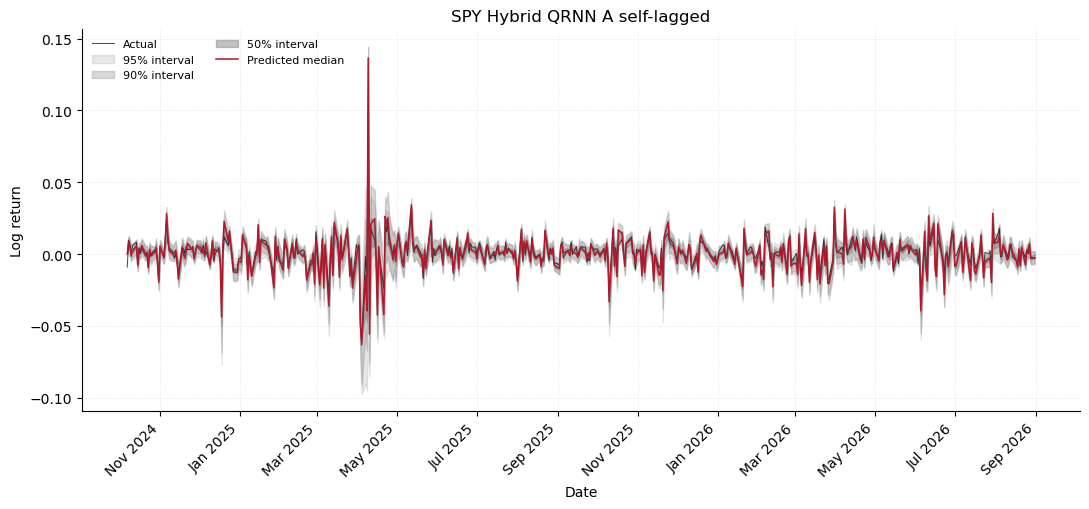


TEST METRICS — SPY HYBRID QRNN A SELF-LAGGED
 alpha       NLL  Hit_Rate      HRE    Sigma  Selected_Trial
 0.025 -3.464032  0.008403 0.016597 0.000309             122
 0.050 -3.707985  0.010504 0.039496 0.000390             161
 0.250 -4.140695  0.199580 0.050420 0.001413             193
 0.500 -4.100298  0.432773 0.067227 0.001715             146
 0.750 -4.243519  0.750000 0.000000 0.001111             141
 0.950 -3.804193  0.941176 0.008824 0.000442             121
 0.975 -3.808773  0.991597 0.016597 0.000294             160

Average NLL: -3.895642
Average HRE: 0.028451

CROSSOVER ANALYSIS — RAW TEST FORECASTS
 Lower_Alpha  Upper_Alpha  Violations  Violation_Rate  Tail_Pair
       0.025        0.050          78        0.163866       True
       0.050        0.250           1        0.002101      False
       0.250        0.500          25        0.052521      False
       0.500        0.750          16        0.033613      False
       0.750        0.950           9        0.018908 

In [9]:
# ============================================================
# TEST EVALUATION AND PLOTTING — SPY HYBRID QRNN A SELF-LAGGED
# Loads saved checkpoints; does not retune any model
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


EVALUATION_MODEL_NAME = "spy_qrnn_a_self"
EVALUATION_FORM = "A"
EVALUATION_LAG = "self"

EVALUATION_LEVELS = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

required_evaluation_objects = [
    "X_test",
    "y_test",
    "test_df",
    "device",
]

missing_evaluation_objects = [
    name
    for name in required_evaluation_objects
    if name not in globals()
]

if missing_evaluation_objects:
    raise RuntimeError(
        "Missing SPY preparation objects: "
        + ", ".join(missing_evaluation_objects)
        + "\nRun only the SPY data-preparation cell, then rerun this cell."
    )

EVALUATION_DIR = (
    Path("spy_original_tuning_results")
    / EVALUATION_MODEL_NAME
)

if not EVALUATION_DIR.exists():
    raise FileNotFoundError(
        f"Results directory not found: {EVALUATION_DIR.resolve()}"
    )


# ------------------------------------------------------------
# 1. Self-contained checkpoint-compatible model
# ------------------------------------------------------------

def evaluation_recurrence(
    y,
    X,
    beta1,
    beta2,
    beta3,
    fnn,
    psi,
):
    fnn_output = fnn(X).squeeze(-1)
    zero_value = y.new_zeros(())
    statistical_forecasts = [zero_value]
    hybrid_forecasts = [zero_value]

    for time_index in range(1, len(y)):
        previous_return = y[time_index - 1]

        if EVALUATION_LAG == "self":
            previous_state = statistical_forecasts[time_index - 1]
        else:
            previous_state = hybrid_forecasts[time_index - 1]

        if EVALUATION_FORM == "S":
            statistical_value = (
                beta1 * previous_state
                + beta2 * torch.abs(previous_return)
            )

        elif EVALUATION_FORM == "A":
            positive_return = torch.clamp(previous_return, min=0)
            negative_return = torch.clamp(-previous_return, min=0)
            statistical_value = (
                beta1 * previous_state
                + beta2 * positive_return
                + beta3 * negative_return
            )

        elif EVALUATION_FORM == "SI":
            absolute_return = torch.abs(previous_return)
            statistical_value = (
                beta1 * previous_state
                + beta2 * absolute_return
                + beta3 * previous_state * absolute_return
            )

        else:
            raise ValueError(f"Unknown form: {EVALUATION_FORM}")

        hybrid_value = (
            psi * statistical_value
            + (1.0 - psi) * fnn_output[time_index]
        )

        statistical_forecasts.append(statistical_value)
        hybrid_forecasts.append(hybrid_value)

    return (
        torch.stack(hybrid_forecasts),
        torch.stack(statistical_forecasts),
    )


class EvaluationHybridQRNN(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.eps = 1e-6
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))

        if EVALUATION_FORM in {"A", "SI"}:
            self.beta3_raw = nn.Parameter(torch.tensor(0.3))
        else:
            self.beta3_raw = None

        self.psi_raw = nn.Parameter(torch.tensor(0.0))
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        layers = []
        previous_dimension = input_dim

        for layer_index in range(config["n_hidden_layers"]):
            hidden_dimension = config[f"hidden_dim_{layer_index}"]
            layers.append(nn.Linear(previous_dimension, hidden_dimension))

            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dimension))

            activation = {
                "relu": nn.ReLU(),
                "elu": nn.ELU(),
                "gelu": nn.GELU(),
                "tanh": nn.Tanh(),
            }[config["activation"]]

            layers.append(activation)

            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))

            previous_dimension = hidden_dimension

        layers.append(nn.Linear(previous_dimension, 1))
        self.fnn = nn.Sequential(*layers)

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)

        beta3 = (
            F.softplus(self.beta3_raw)
            if self.beta3_raw is not None
            else None
        )

        psi = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps

        hybrid_forecast, statistical_forecast = evaluation_recurrence(
            y=y,
            X=X,
            beta1=beta1,
            beta2=beta2,
            beta3=beta3,
            fnn=self.fnn,
            psi=psi,
        )

        return hybrid_forecast, sigma, statistical_forecast


# ------------------------------------------------------------
# 2. Evaluation functions
# ------------------------------------------------------------

def evaluation_ald_nll(y, forecast, sigma, alpha):
    sigma = torch.clamp(
        sigma,
        min=torch.finfo(forecast.dtype).eps,
    )

    alpha_tensor = torch.as_tensor(
        alpha,
        dtype=forecast.dtype,
        device=forecast.device,
    )

    residual = y - forecast
    indicator = (residual < 0).to(forecast.dtype)
    check_loss = residual * (alpha_tensor - indicator)

    observation_nll = (
        -torch.log(alpha_tensor * (1.0 - alpha_tensor))
        + torch.log(sigma)
        + check_loss / sigma
    )

    return observation_nll


# ------------------------------------------------------------
# 3. Load each selected checkpoint and forecast the test sample
# ------------------------------------------------------------

test_forecast_columns = []
test_nll_columns = []
test_metric_records = []
loaded_test_models = {}

for alpha in EVALUATION_LEVELS:
    alpha_label = f"{alpha:.3f}"

    checkpoint_path = EVALUATION_DIR / (
        f"{EVALUATION_MODEL_NAME}_best_alpha_{alpha_label}.pt"
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Missing checkpoint: {checkpoint_path.resolve()}"
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model = EvaluationHybridQRNN(
        input_dim=X_test.shape[1],
        config=checkpoint["config"],
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    with torch.no_grad():
        forecast, sigma, _ = model(y_test, X_test)

        observation_nll = evaluation_ald_nll(
            y=y_test,
            forecast=forecast,
            sigma=sigma,
            alpha=alpha,
        )

    forecast_np = forecast.detach().cpu().numpy()
    nll_np = observation_nll.detach().cpu().numpy()
    y_test_np = y_test.detach().cpu().numpy()

    hit_rate = float(np.mean(y_test_np <= forecast_np))
    hre = abs(hit_rate - alpha)

    test_forecast_columns.append(forecast_np)
    test_nll_columns.append(nll_np)
    loaded_test_models[alpha] = model

    test_metric_records.append({
        "alpha": alpha,
        "NLL": float(np.mean(nll_np)),
        "Hit_Rate": hit_rate,
        "HRE": hre,
        "Sigma": float(sigma.detach().cpu().item()),
        "Selected_Trial": checkpoint["selected_trial"],
    })


test_forecast_matrix = np.column_stack(test_forecast_columns)
test_nll_matrix = np.column_stack(test_nll_columns)
test_metrics = pd.DataFrame(test_metric_records)


# ------------------------------------------------------------
# 4. Crossover diagnostics
# ------------------------------------------------------------

crossover_records = []
total_crossovers = 0
tail_crossovers = 0

for pair_index in range(len(EVALUATION_LEVELS) - 1):
    lower_level = EVALUATION_LEVELS[pair_index]
    upper_level = EVALUATION_LEVELS[pair_index + 1]

    violation_mask = (
        test_forecast_matrix[:, pair_index]
        > test_forecast_matrix[:, pair_index + 1]
    )

    violations = int(violation_mask.sum())
    violation_rate = violations / len(test_df)
    is_tail_pair = pair_index in {0, len(EVALUATION_LEVELS) - 2}

    total_crossovers += violations

    if is_tail_pair:
        tail_crossovers += violations

    crossover_records.append({
        "Lower_Alpha": lower_level,
        "Upper_Alpha": upper_level,
        "Violations": violations,
        "Violation_Rate": violation_rate,
        "Tail_Pair": is_tail_pair,
    })

crossover_table = pd.DataFrame(crossover_records)


# ------------------------------------------------------------
# 5. Save predictions, observation-level NLL and metrics
# ------------------------------------------------------------

predictions_table = pd.DataFrame({
    "Date": test_df.index,
    "Actual": y_test.detach().cpu().numpy(),
})

nll_table = pd.DataFrame({
    "Date": test_df.index,
})

for level_index, alpha in enumerate(EVALUATION_LEVELS):
    predictions_table[f"q_{alpha:.3f}"] = (
        test_forecast_matrix[:, level_index]
    )

    nll_table[f"nll_{alpha:.3f}"] = (
        test_nll_matrix[:, level_index]
    )

nll_table["average_nll_across_levels"] = (
    test_nll_matrix.mean(axis=1)
)

predictions_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_predictions.csv"
)

nll_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_nll_by_date.csv"
)

metrics_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_metrics.csv"
)

crossover_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_crossovers.csv"
)

predictions_table.to_csv(predictions_path, index=False)
nll_table.to_csv(nll_path, index=False)
test_metrics.to_csv(metrics_path, index=False)
crossover_table.to_csv(crossover_path, index=False)


# ------------------------------------------------------------
# 6. Test-period prediction plot
# Bitcoin-style presentation: black actual, red median,
# and grey 50%, 90%, and 95% interval bands
# ------------------------------------------------------------

dates = test_df.index
actual = y_test.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(11, 5.2))

ax.plot(
    dates,
    actual,
    color="black",
    linewidth=0.75,
    alpha=0.70,
    label="Actual",
)

ax.fill_between(
    dates,
    test_forecast_matrix[:, 0],
    test_forecast_matrix[:, 6],
    color="grey",
    alpha=0.18,
    label="95% interval",
)

ax.fill_between(
    dates,
    test_forecast_matrix[:, 1],
    test_forecast_matrix[:, 5],
    color="grey",
    alpha=0.30,
    label="90% interval",
)

ax.fill_between(
    dates,
    test_forecast_matrix[:, 2],
    test_forecast_matrix[:, 4],
    color="grey",
    alpha=0.48,
    label="50% interval",
)

ax.plot(
    dates,
    test_forecast_matrix[:, 3],
    color="#B2182B",
    linewidth=1.1,
    label="Predicted median",
)

ax.set(
    title=(
        f"SPY Hybrid QRNN {EVALUATION_FORM} "
        f"{EVALUATION_LAG}-lagged"
    ),
    xlabel="Date",
    ylabel="Log return",
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha="right",
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.5,
    alpha=0.45,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=8,
    ncol=2,
    loc="upper left",
)

fig.tight_layout()

plot_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_predictions.png"
)

fig.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 7. Display concise results
# ------------------------------------------------------------

print("\n" + "=" * 72)
print(
    "TEST METRICS — SPY HYBRID QRNN "
    "A SELF-LAGGED"
)
print("=" * 72)
print(test_metrics.to_string(index=False))

print("\nAverage NLL:", f"{test_metrics['NLL'].mean():.6f}")
print("Average HRE:", f"{test_metrics['HRE'].mean():.6f}")

print("\n" + "=" * 72)
print("CROSSOVER ANALYSIS — RAW TEST FORECASTS")
print("=" * 72)
print(crossover_table.to_string(index=False))

print("\nTotal crossover violations:", total_crossovers)
print("Tail crossover violations:", tail_crossovers)

print("\nSaved outputs:")
print("Predictions:", predictions_path)
print("Observation-level NLL:", nll_path)
print("Metrics:", metrics_path)
print("Crossovers:", crossover_path)
print("Plot:", plot_path)


## Crossover - Sorting


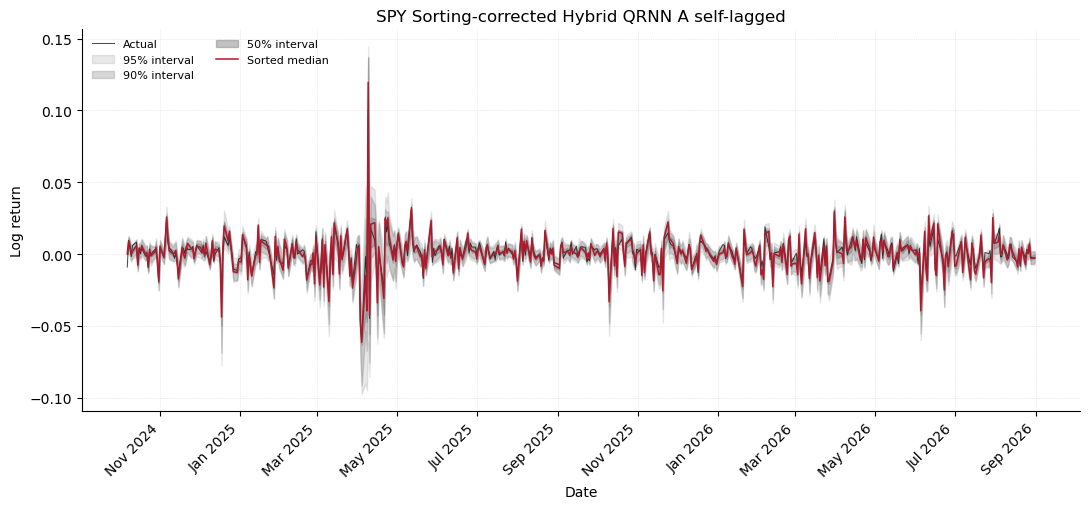

TEST METRICS — SORTING SPY QRNN A SELF-LAGGED
     alpha  raw_test_nll  sorted_test_nll  raw_hit_rate  sorted_hit_rate    raw_hre  sorted_hre  mean_absolute_adjustment
0.02500000   -3.46403198      -3.46718693    0.00840336       0.00630252 0.01659664  0.01869748                0.00013215
0.05000000   -3.70798564      -3.70761454    0.01050420       0.01260504 0.03949580  0.03739496                0.00018161
0.25000000   -4.14069485      -4.13409407    0.19957983       0.19327731 0.05042017  0.05672269                0.00020087
0.50000000   -4.10029795      -4.15732292    0.43277311       0.43277311 0.06722689  0.06722689                0.00022470
0.75000000   -4.24351946      -4.24988856    0.75000000       0.75000000 0.00000000  0.00000000                0.00008188
0.95000000   -3.80419223      -3.90670871    0.94117647       0.94327731 0.00882353  0.00672269                0.00077594
0.97500000   -3.80877343      -3.74950091    0.99159664       0.99579832 0.01659664  0.02079832     

In [12]:
# ============================================================
# CROSSOVER METHOD: POST-PROCESSING SORTING
# SPY HYBRID QRNN A — SELF-LAGGED
# Uses saved unrestricted forecasts; no retuning is required
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ------------------------------------------------------------
# 1. Settings and saved original results
# ------------------------------------------------------------

SORTING_LEVELS = np.array([
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
], dtype=float)

ORIGINAL_MODEL_NAME = "spy_qrnn_a_self"

ORIGINAL_RESULT_DIR = (
    Path("spy_original_tuning_results")
    / ORIGINAL_MODEL_NAME
)

SORTING_OUTPUT_DIR = (
    Path("spy_sorting_crossover_results")
    / ORIGINAL_MODEL_NAME
)
SORTING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

predictions_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_predictions.csv"
)
metrics_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_metrics.csv"
)

if not predictions_path.exists():
    raise FileNotFoundError(
        f"Original prediction file not found: {predictions_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )

if not metrics_path.exists():
    raise FileNotFoundError(
        f"Original metric file not found: {metrics_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )


# ------------------------------------------------------------
# 2. Load unrestricted forecasts and sort each date independently
# ------------------------------------------------------------

raw_table = pd.read_csv(predictions_path, parse_dates=["Date"])
original_metrics = pd.read_csv(metrics_path)

quantile_columns = [f"q_{alpha:.3f}" for alpha in SORTING_LEVELS]
missing_columns = [
    column for column in ["Date", "Actual", *quantile_columns]
    if column not in raw_table.columns
]

if missing_columns:
    raise ValueError(
        "Missing columns in saved prediction file: "
        + ", ".join(missing_columns)
    )

raw_forecasts = raw_table[quantile_columns].to_numpy(dtype=float)
sorted_forecasts = np.sort(raw_forecasts, axis=1)
actual = raw_table["Actual"].to_numpy(dtype=float)
dates = pd.to_datetime(raw_table["Date"])

if len(original_metrics) != len(SORTING_LEVELS):
    raise ValueError("The saved metric file must contain all seven levels.")

sigma_by_level = (
    original_metrics
    .assign(alpha=original_metrics["alpha"].astype(float))
    .set_index("alpha")["Sigma"]
)


# ------------------------------------------------------------
# 3. Recalculate ALD NLL, coverage and HRE after sorting
# ------------------------------------------------------------

def ald_nll_by_observation(y, forecast, sigma, alpha):
    sigma = max(float(sigma), np.finfo(float).eps)
    residual = y - forecast
    indicator = (residual < 0.0).astype(float)
    check_loss = residual * (float(alpha) - indicator)

    return (
        -np.log(float(alpha) * (1.0 - float(alpha)))
        + np.log(sigma)
        + check_loss / sigma
    )


metric_records = []
raw_nll_columns = []
sorted_nll_columns = []

for level_index, alpha in enumerate(SORTING_LEVELS):
    sigma = float(sigma_by_level.loc[alpha])
    raw_forecast = raw_forecasts[:, level_index]
    sorted_forecast = sorted_forecasts[:, level_index]

    raw_nll = ald_nll_by_observation(
        actual, raw_forecast, sigma, alpha
    )
    sorted_nll = ald_nll_by_observation(
        actual, sorted_forecast, sigma, alpha
    )

    raw_hit_rate = float(np.mean(actual <= raw_forecast))
    sorted_hit_rate = float(np.mean(actual <= sorted_forecast))

    raw_nll_columns.append(raw_nll)
    sorted_nll_columns.append(sorted_nll)

    metric_records.append({
        "alpha": alpha,
        "raw_test_nll": float(np.mean(raw_nll)),
        "sorted_test_nll": float(np.mean(sorted_nll)),
        "raw_hit_rate": raw_hit_rate,
        "sorted_hit_rate": sorted_hit_rate,
        "raw_hre": abs(raw_hit_rate - alpha),
        "sorted_hre": abs(sorted_hit_rate - alpha),
        "mean_absolute_adjustment": float(
            np.mean(np.abs(sorted_forecast - raw_forecast))
        ),
    })

sorting_metrics = pd.DataFrame(metric_records)
raw_nll_matrix = np.column_stack(raw_nll_columns)
sorted_nll_matrix = np.column_stack(sorted_nll_columns)


# ------------------------------------------------------------
# 4. Crossover and adjustment diagnostics
# ------------------------------------------------------------

def crossover_summary(forecast_matrix):
    pair_records = []
    total = 0
    tail = 0

    for pair_index in range(len(SORTING_LEVELS) - 1):
        violation_mask = (
            forecast_matrix[:, pair_index]
            > forecast_matrix[:, pair_index + 1]
        )
        count = int(violation_mask.sum())
        is_tail = pair_index in {0, len(SORTING_LEVELS) - 2}
        total += count
        if is_tail:
            tail += count

        pair_records.append({
            "lower_alpha": SORTING_LEVELS[pair_index],
            "upper_alpha": SORTING_LEVELS[pair_index + 1],
            "violations": count,
            "violation_rate": count / len(forecast_matrix),
            "tail_pair": is_tail,
        })

    return total, tail, pd.DataFrame(pair_records)


raw_crossover, raw_tail, raw_pair_table = crossover_summary(
    raw_forecasts
)
sorted_crossover, sorted_tail, sorted_pair_table = crossover_summary(
    sorted_forecasts
)

adjustment_matrix = sorted_forecasts - raw_forecasts
changed_rows = np.any(
    ~np.isclose(adjustment_matrix, 0.0, atol=1e-12),
    axis=1,
)


# ------------------------------------------------------------
# 5. Save all sorting results
# ------------------------------------------------------------

sorted_prediction_table = pd.DataFrame({
    "Date": dates,
    "Actual": actual,
})

for level_index, alpha in enumerate(SORTING_LEVELS):
    sorted_prediction_table[f"raw_q_{alpha:.3f}"] = (
        raw_forecasts[:, level_index]
    )
    sorted_prediction_table[f"sorted_q_{alpha:.3f}"] = (
        sorted_forecasts[:, level_index]
    )

sorting_nll_by_date = pd.DataFrame({"Date": dates})
for level_index, alpha in enumerate(SORTING_LEVELS):
    sorting_nll_by_date[f"raw_nll_{alpha:.3f}"] = (
        raw_nll_matrix[:, level_index]
    )
    sorting_nll_by_date[f"sorted_nll_{alpha:.3f}"] = (
        sorted_nll_matrix[:, level_index]
    )
sorting_nll_by_date["raw_average_nll"] = raw_nll_matrix.mean(axis=1)
sorting_nll_by_date["sorted_average_nll"] = (
    sorted_nll_matrix.mean(axis=1)
)

sorting_summary = pd.DataFrame([{
    "model": ORIGINAL_MODEL_NAME,
    "test_T": len(actual),
    "raw_average_nll": sorting_metrics["raw_test_nll"].mean(),
    "sorted_average_nll": sorting_metrics["sorted_test_nll"].mean(),
    "raw_average_hre": sorting_metrics["raw_hre"].mean(),
    "sorted_average_hre": sorting_metrics["sorted_hre"].mean(),
    "raw_crossover": raw_crossover,
    "sorted_crossover": sorted_crossover,
    "raw_tail": raw_tail,
    "sorted_tail": sorted_tail,
    "changed_observations": int(changed_rows.sum()),
    "mean_absolute_adjustment": float(
        np.mean(np.abs(adjustment_matrix))
    ),
    "maximum_absolute_adjustment": float(
        np.max(np.abs(adjustment_matrix))
    ),
}])

sorted_prediction_table.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_predictions.csv",
    index=False,
)
sorting_metrics.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_metrics.csv",
    index=False,
)
sorting_nll_by_date.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_nll_by_date.csv",
    index=False,
)
raw_pair_table.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_raw_crossovers.csv",
    index=False,
)
sorted_pair_table.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_crossovers.csv",
    index=False,
)
sorting_summary.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 6. Bitcoin-style plot: black actual, red median, grey bands
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.2))

ax.plot(
    dates,
    actual,
    color="black",
    linewidth=0.75,
    alpha=0.70,
    label="Actual",
)

ax.fill_between(
    dates,
    sorted_forecasts[:, 0],
    sorted_forecasts[:, 6],
    color="grey",
    alpha=0.18,
    label="95% interval",
)

ax.fill_between(
    dates,
    sorted_forecasts[:, 1],
    sorted_forecasts[:, 5],
    color="grey",
    alpha=0.30,
    label="90% interval",
)

ax.fill_between(
    dates,
    sorted_forecasts[:, 2],
    sorted_forecasts[:, 4],
    color="grey",
    alpha=0.48,
    label="50% interval",
)

ax.plot(
    dates,
    sorted_forecasts[:, 3],
    color="#B2182B",
    linewidth=1.1,
    label="Sorted median",
)

ax.set(
    title="SPY Sorting-corrected Hybrid QRNN A self-lagged",
    xlabel="Date",
    ylabel="Log return",
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha="right",
)

ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")

fig.tight_layout()

plot_path = SORTING_OUTPUT_DIR / (
    f"sorting_{ORIGINAL_MODEL_NAME}_predictions.png"
)
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 7. Report
# ------------------------------------------------------------

print("=" * 79)
print("TEST METRICS — SORTING SPY QRNN A SELF-LAGGED")
print("=" * 79)
print(sorting_metrics.to_string(index=False, float_format=lambda x: f"{x:.8f}"))

print("\n" + "=" * 79)
print("SUMMARY")
print("=" * 79)
print(f"Raw average NLL:         {sorting_summary.loc[0, 'raw_average_nll']:.6f}")
print(f"Sorted average NLL:      {sorting_summary.loc[0, 'sorted_average_nll']:.6f}")
print(f"Raw average HRE:         {sorting_summary.loc[0, 'raw_average_hre']:.6f}")
print(f"Sorted average HRE:      {sorting_summary.loc[0, 'sorted_average_hre']:.6f}")
print(f"Raw crossover:           {raw_crossover}")
print(f"Sorted crossover:        {sorted_crossover}")
print(f"Raw tail violations:     {raw_tail}")
print(f"Sorted tail violations:  {sorted_tail}")
print(f"Changed observations:    {int(changed_rows.sum())}/{len(actual)}")
print(
    "Mean adjustment:         "
    f"{np.mean(np.abs(adjustment_matrix)):.8f}"
)
print(
    "Maximum adjustment:      "
    f"{np.max(np.abs(adjustment_matrix)):.8f}"
)
print(f"\nPlot saved to:\n{plot_path}")
print(f"\nAll sorting results saved under:\n{SORTING_OUTPUT_DIR}")


## Crossover - PAVA


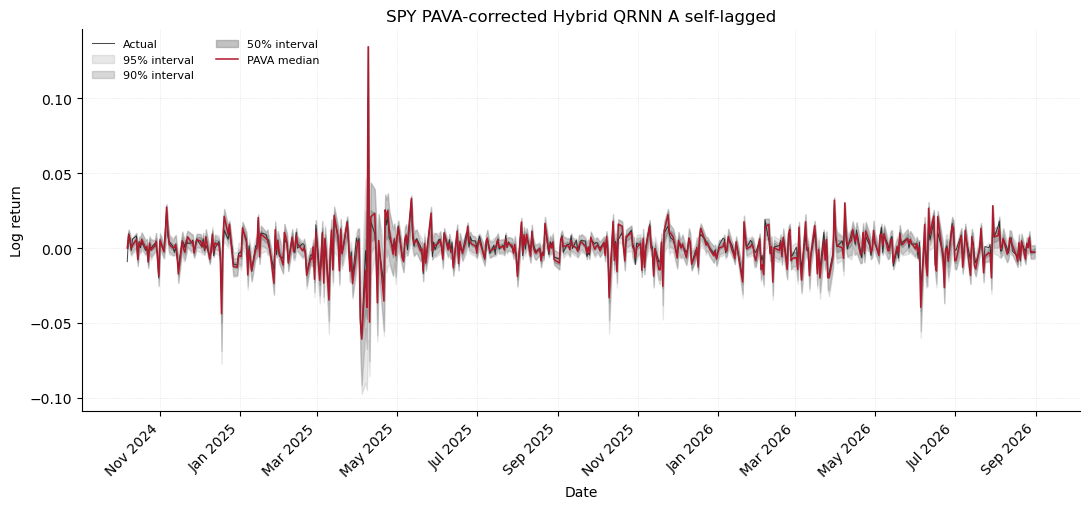

TEST METRICS — EQUAL-WEIGHT PAVA SPY QRNN A SELF-LAGGED
     alpha     raw_nll    pava_nll  raw_pinball  pava_pinball  raw_hit_rate  pava_hit_rate    raw_hre   pava_hre  mean_absolute_adjustment
0.02500000 -3.46403198 -3.46813766   0.00027931    0.00027804    0.00840336     0.00840336 0.01659664 0.01659664                0.00006607
0.05000000 -3.70798564 -3.70980229   0.00042683    0.00042612    0.01050420     0.01260504 0.03949580 0.03739496                0.00009081
0.25000000 -4.14069485 -4.14067610   0.00105614    0.00105616    0.19957983     0.19537815 0.05042017 0.05462185                0.00010129
0.50000000 -4.10029795 -4.12696718   0.00151220    0.00146647    0.43277311     0.43277311 0.06722689 0.06722689                0.00009930
0.75000000 -4.24351946 -4.24447146   0.00098326    0.00098220    0.75000000     0.74789916 0.00000000 0.00210084                0.00004858
0.95000000 -3.80419223 -3.86079080   0.00038580    0.00036076    0.94117647     0.94117647 0.00882353 0.008823

In [15]:
# ============================================================
# CROSSOVER METHOD: EQUAL-WEIGHT PAVA
# SPY HYBRID QRNN A — SELF-LAGGED
# Uses saved unrestricted forecasts; no retuning is required
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ------------------------------------------------------------
# 1. Settings and saved original results
# ------------------------------------------------------------

PAVA_LEVELS = np.array([
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
], dtype=float)

ORIGINAL_MODEL_NAME = "spy_qrnn_a_self"

ORIGINAL_RESULT_DIR = (
    Path("spy_original_tuning_results")
    / ORIGINAL_MODEL_NAME
)

PAVA_OUTPUT_DIR = (
    Path("spy_pava_crossover_results")
    / ORIGINAL_MODEL_NAME
)
PAVA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

predictions_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_predictions.csv"
)
metrics_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_metrics.csv"
)

if not predictions_path.exists():
    raise FileNotFoundError(
        f"Original prediction file not found: {predictions_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )

if not metrics_path.exists():
    raise FileNotFoundError(
        f"Original metric file not found: {metrics_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )


# ------------------------------------------------------------
# 2. Equal-weight PAVA
# ------------------------------------------------------------

def equal_weight_pava(values):
    """Least-squares projection onto a nondecreasing sequence."""
    values = np.asarray(values, dtype=float)

    block_values = []
    block_weights = []
    block_starts = []
    block_ends = []

    for index, value in enumerate(values):
        block_values.append(float(value))
        block_weights.append(1.0)
        block_starts.append(index)
        block_ends.append(index)

        while (
            len(block_values) >= 2
            and block_values[-2] > block_values[-1]
        ):
            merged_weight = block_weights[-2] + block_weights[-1]
            merged_value = (
                block_weights[-2] * block_values[-2]
                + block_weights[-1] * block_values[-1]
            ) / merged_weight
            merged_start = block_starts[-2]
            merged_end = block_ends[-1]

            block_values[-2:] = [merged_value]
            block_weights[-2:] = [merged_weight]
            block_starts[-2:] = [merged_start]
            block_ends[-2:] = [merged_end]

    projected = np.empty_like(values, dtype=float)
    for value, start, end in zip(
        block_values,
        block_starts,
        block_ends,
    ):
        projected[start:end + 1] = value

    return projected


# ------------------------------------------------------------
# 3. Load unrestricted forecasts and project every test date
# ------------------------------------------------------------

raw_table = pd.read_csv(predictions_path, parse_dates=["Date"])
original_metrics = pd.read_csv(metrics_path)

quantile_columns = [f"q_{alpha:.3f}" for alpha in PAVA_LEVELS]
missing_columns = [
    column for column in ["Date", "Actual", *quantile_columns]
    if column not in raw_table.columns
]

if missing_columns:
    raise ValueError(
        "Missing columns in saved prediction file: "
        + ", ".join(missing_columns)
    )

raw_forecasts = raw_table[quantile_columns].to_numpy(dtype=float)
pava_forecasts = np.vstack([
    equal_weight_pava(row)
    for row in raw_forecasts
])

actual = raw_table["Actual"].to_numpy(dtype=float)
dates = pd.to_datetime(raw_table["Date"])

if len(original_metrics) != len(PAVA_LEVELS):
    raise ValueError("The saved metric file must contain all seven levels.")

sigma_by_level = (
    original_metrics
    .assign(alpha=original_metrics["alpha"].astype(float))
    .set_index("alpha")["Sigma"]
)


# ------------------------------------------------------------
# 4. Recalculate ALD NLL, pinball loss, coverage and HRE
# ------------------------------------------------------------

def pinball_by_observation(y, forecast, alpha):
    residual = y - forecast
    indicator = (residual < 0.0).astype(float)
    return residual * (float(alpha) - indicator)


def ald_nll_by_observation(y, forecast, sigma, alpha):
    sigma = max(float(sigma), np.finfo(float).eps)
    return (
        -np.log(float(alpha) * (1.0 - float(alpha)))
        + np.log(sigma)
        + pinball_by_observation(y, forecast, alpha) / sigma
    )


metric_records = []
raw_nll_columns = []
pava_nll_columns = []

for level_index, alpha in enumerate(PAVA_LEVELS):
    sigma = float(sigma_by_level.loc[alpha])
    raw_forecast = raw_forecasts[:, level_index]
    pava_forecast = pava_forecasts[:, level_index]

    raw_pinball = pinball_by_observation(actual, raw_forecast, alpha)
    pava_pinball = pinball_by_observation(actual, pava_forecast, alpha)
    raw_nll = ald_nll_by_observation(
        actual, raw_forecast, sigma, alpha
    )
    pava_nll = ald_nll_by_observation(
        actual, pava_forecast, sigma, alpha
    )

    raw_hit_rate = float(np.mean(actual <= raw_forecast))
    pava_hit_rate = float(np.mean(actual <= pava_forecast))

    raw_nll_columns.append(raw_nll)
    pava_nll_columns.append(pava_nll)

    metric_records.append({
        "alpha": alpha,
        "raw_nll": float(np.mean(raw_nll)),
        "pava_nll": float(np.mean(pava_nll)),
        "raw_pinball": float(np.mean(raw_pinball)),
        "pava_pinball": float(np.mean(pava_pinball)),
        "raw_hit_rate": raw_hit_rate,
        "pava_hit_rate": pava_hit_rate,
        "raw_hre": abs(raw_hit_rate - alpha),
        "pava_hre": abs(pava_hit_rate - alpha),
        "mean_absolute_adjustment": float(
            np.mean(np.abs(pava_forecast - raw_forecast))
        ),
    })

pava_metrics = pd.DataFrame(metric_records)
raw_nll_matrix = np.column_stack(raw_nll_columns)
pava_nll_matrix = np.column_stack(pava_nll_columns)


# ------------------------------------------------------------
# 5. Crossover and adjustment diagnostics
# ------------------------------------------------------------

def crossover_summary(forecast_matrix):
    pair_records = []
    total = 0
    tail = 0

    for pair_index in range(len(PAVA_LEVELS) - 1):
        violation_mask = (
            forecast_matrix[:, pair_index]
            > forecast_matrix[:, pair_index + 1]
        )
        count = int(violation_mask.sum())
        is_tail = pair_index in {0, len(PAVA_LEVELS) - 2}
        total += count
        if is_tail:
            tail += count

        pair_records.append({
            "lower_alpha": PAVA_LEVELS[pair_index],
            "upper_alpha": PAVA_LEVELS[pair_index + 1],
            "violations": count,
            "violation_rate": count / len(forecast_matrix),
            "tail_pair": is_tail,
        })

    return total, tail, pd.DataFrame(pair_records)


raw_crossover, raw_tail, raw_pair_table = crossover_summary(
    raw_forecasts
)
pava_crossover, pava_tail, pava_pair_table = crossover_summary(
    pava_forecasts
)

adjustment_matrix = pava_forecasts - raw_forecasts
changed_rows = np.any(
    ~np.isclose(adjustment_matrix, 0.0, atol=1e-12),
    axis=1,
)


# ------------------------------------------------------------
# 6. Save all PAVA results
# ------------------------------------------------------------

pava_prediction_table = pd.DataFrame({
    "Date": dates,
    "Actual": actual,
})

for level_index, alpha in enumerate(PAVA_LEVELS):
    pava_prediction_table[f"raw_q_{alpha:.3f}"] = (
        raw_forecasts[:, level_index]
    )
    pava_prediction_table[f"pava_q_{alpha:.3f}"] = (
        pava_forecasts[:, level_index]
    )

pava_nll_by_date = pd.DataFrame({"Date": dates})
for level_index, alpha in enumerate(PAVA_LEVELS):
    pava_nll_by_date[f"raw_nll_{alpha:.3f}"] = (
        raw_nll_matrix[:, level_index]
    )
    pava_nll_by_date[f"pava_nll_{alpha:.3f}"] = (
        pava_nll_matrix[:, level_index]
    )
pava_nll_by_date["raw_average_nll"] = raw_nll_matrix.mean(axis=1)
pava_nll_by_date["pava_average_nll"] = pava_nll_matrix.mean(axis=1)

pava_summary = pd.DataFrame([{
    "model": ORIGINAL_MODEL_NAME,
    "test_T": len(actual),
    "raw_average_nll": pava_metrics["raw_nll"].mean(),
    "pava_average_nll": pava_metrics["pava_nll"].mean(),
    "raw_average_hre": pava_metrics["raw_hre"].mean(),
    "pava_average_hre": pava_metrics["pava_hre"].mean(),
    "raw_total_pinball": pava_metrics["raw_pinball"].sum(),
    "pava_total_pinball": pava_metrics["pava_pinball"].sum(),
    "raw_crossover": raw_crossover,
    "pava_crossover": pava_crossover,
    "raw_tail": raw_tail,
    "pava_tail": pava_tail,
    "changed_observations": int(changed_rows.sum()),
    "mean_absolute_adjustment": float(
        np.mean(np.abs(adjustment_matrix))
    ),
    "maximum_absolute_adjustment": float(
        np.max(np.abs(adjustment_matrix))
    ),
}])

pava_prediction_table.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_predictions.csv",
    index=False,
)
pava_metrics.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_metrics.csv",
    index=False,
)
pava_nll_by_date.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_nll_by_date.csv",
    index=False,
)
raw_pair_table.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_raw_crossovers.csv",
    index=False,
)
pava_pair_table.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_crossovers.csv",
    index=False,
)
pava_summary.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 7. Bitcoin-style plot: black actual, red median, grey bands
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.2))

ax.plot(
    dates,
    actual,
    color="black",
    linewidth=0.75,
    alpha=0.70,
    label="Actual",
)

ax.fill_between(
    dates,
    pava_forecasts[:, 0],
    pava_forecasts[:, 6],
    color="grey",
    alpha=0.18,
    label="95% interval",
)

ax.fill_between(
    dates,
    pava_forecasts[:, 1],
    pava_forecasts[:, 5],
    color="grey",
    alpha=0.30,
    label="90% interval",
)

ax.fill_between(
    dates,
    pava_forecasts[:, 2],
    pava_forecasts[:, 4],
    color="grey",
    alpha=0.48,
    label="50% interval",
)

ax.plot(
    dates,
    pava_forecasts[:, 3],
    color="#B2182B",
    linewidth=1.1,
    label="PAVA median",
)

ax.set(
    title="SPY PAVA-corrected Hybrid QRNN A self-lagged",
    xlabel="Date",
    ylabel="Log return",
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha="right",
)

ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")

fig.tight_layout()

plot_path = PAVA_OUTPUT_DIR / (
    f"pava_{ORIGINAL_MODEL_NAME}_predictions.png"
)
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 8. Report
# ------------------------------------------------------------

print("=" * 79)
print("TEST METRICS — EQUAL-WEIGHT PAVA SPY QRNN A SELF-LAGGED")
print("=" * 79)
print(pava_metrics.to_string(index=False, float_format=lambda x: f"{x:.8f}"))

print("\n" + "=" * 79)
print("SUMMARY")
print("=" * 79)
print(f"Raw average NLL:       {pava_summary.loc[0, 'raw_average_nll']:.6f}")
print(f"PAVA average NLL:      {pava_summary.loc[0, 'pava_average_nll']:.6f}")
print(f"Raw average HRE:       {pava_summary.loc[0, 'raw_average_hre']:.6f}")
print(f"PAVA average HRE:      {pava_summary.loc[0, 'pava_average_hre']:.6f}")
print(f"Raw total pinball:     {pava_summary.loc[0, 'raw_total_pinball']:.8f}")
print(f"PAVA total pinball:    {pava_summary.loc[0, 'pava_total_pinball']:.8f}")
print(f"Raw crossover:         {raw_crossover}")
print(f"PAVA crossover:        {pava_crossover}")
print(f"Raw tail violations:   {raw_tail}")
print(f"PAVA tail violations:  {pava_tail}")
print(f"Changed observations:  {int(changed_rows.sum())}/{len(actual)}")
print(
    "Mean adjustment:       "
    f"{np.mean(np.abs(adjustment_matrix)):.8f}"
)
print(
    "Maximum adjustment:    "
    f"{np.max(np.abs(adjustment_matrix)):.8f}"
)
print(f"\nPlot saved to:\n{plot_path}")
print(f"\nAll PAVA results saved under:\n{PAVA_OUTPUT_DIR}")
